# Coding Session 04 · Lab W4

## Today's plan

- Compare multiple call arms against a shared control.
- Write loops and distinguish a pre-specified contrast from a selected winner.
- Preserve the assignment design in a selection-aware null simulation.
- Revisit NY grouped summaries and denominator checks as additional practice.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## From geographic tables to an experiment

The existing course file is the Kling and Stratmann partisan robocall experiment: one row is a registered voter, `group` is assignment to no calls, one, three, or six calls, and `voted` records turnout. `treatment` means assignment to any call arm, not confirmed receipt. `gen2012`, `age`, `income`, `male`, and `svh` are pre-treatment covariates. `svh` marks single-voter households.

Source: Kling and Stratmann (2023), [Large-Scale Evidence for the Effectiveness of Partisan GOTV Robo Calls](https://doi.org/10.1017/XPS.2022.16), using the course's existing extract.

**What this file can teach:** assignment contrasts, code for randomization inference, and subgroup summaries. It has no household or randomization-block identifiers. The permutation examples below therefore use an explicitly simplified model of individual complete random assignment; they are not a replication of the paper's design or publication-level uncertainty. Do not interpret turnout as persuasion, successful contact, or net votes for a candidate.


In [2]:
from pathlib import Path

# Works from a session folder, the repository root, or a fresh Colab notebook.
data_candidates = [
    Path("data/kling_stratmann_subset.csv"),
    Path("wk09_cost_effectiveness/data/kling_stratmann_subset.csv"),
    Path("../wk09_cost_effectiveness/data/kling_stratmann_subset.csv"),
]
data_path = next((p for p in data_candidates if p.exists()), None)
data_url = "https://raw.githubusercontent.com/albertostefanelli/DSPC_coding_sessions/master/wk09_cost_effectiveness/data/kling_stratmann_subset.csv"
calls = pd.read_csv(data_path if data_path is not None else data_url)
calls.head()


,age,income,male,svh,gen2012,treatment,group,voted
0,38.0,100000.0,1.0,0,1,1,T1: 1 Call,1
1,36.0,100000.0,0.0,0,1,1,T1: 1 Call,0
2,64.0,75000.0,1.0,0,0,0,Control (No Call),0
3,63.0,75000.0,0.0,0,0,0,Control (No Call),0
4,21.0,100000.0,0.0,0,0,0,Control (No Call),0


## Multi-arm contrasts

The lab compares persuasion messages and measures vote intention. Here we retain the existing robocall data and compare **assigned call intensity**, with actual turnout as the outcome. The grouping, loop, and selection logic transfer; neither a positive turnout contrast nor its largest arm tells us which message changes vote choice.


In [3]:
arm_order = ["Control (No Call)", "T1: 1 Call", "T3: 3 Calls", "T6: 6 Calls"]
arm_summary = calls.groupby("group")["voted"].agg(n="count", turnout="mean").reindex(arm_order)
arm_summary["effect_pp"] = 100 * (arm_summary["turnout"] - arm_summary.loc[arm_order[0], "turnout"])
arm_summary


,n,turnout,effect_pp
group,,,
Control (No Call),135331,0.488639,0.000000
T1: 1 Call,135920,0.490833,0.219388
T3: 3 Calls,134826,0.495112,0.647325
T6: 6 Calls,133490,0.489437,0.079844


### A loop is a repeated sequence of steps

The `for` line chooses one label at a time. Its indented body runs for that label. Start with an empty list, append one record on each iteration, then turn the records into a table. Run a single iteration by hand before using the loop.


In [4]:
records = []
control_mean = arm_summary.loc[arm_order[0], "turnout"]
for arm in arm_order[1:]:
    arm_mean = arm_summary.loc[arm, "turnout"]
    records.append({"arm": arm, "effect_pp": 100 * (arm_mean - control_mean)})
contrast_table = pd.DataFrame(records)
contrast_table


,arm,effect_pp
0,T1: 1 Call,0.219388
1,T3: 3 Calls,0.647325
2,T6: 6 Calls,0.079844


## A pre-specified contrast and a selected winner

For fast practice, sample 800 voters from each of the four arms using only assignment labels and a fixed seed. This sample has equal arm sizes; it is not the original full study. We condition on those sizes in our simplified individual-assignment model. Decide which statistic answers the question **before** reading the results: the one-call contrast if that was pre-specified, or the largest absolute contrast if we searched all arms in both directions.


In [5]:
experiment = pd.concat([
    calls.loc[calls["group"] == arm].sample(n=800, random_state=410 + i)
    for i, arm in enumerate(arm_order)
]).reset_index(drop=True)
y = experiment["voted"].to_numpy()
z = experiment["group"].to_numpy()

def arm_contrasts(outcomes, assignment):
    control = outcomes[assignment == arm_order[0]].mean()
    return np.array([
        outcomes[assignment == arm].mean() - control
        for arm in arm_order[1:]
    ])

observed = arm_contrasts(y, z)
print(pd.Series(100 * observed, index=arm_order[1:], name="sample_effect_pp"))


T1: 1 Call    -4.625
T3: 3 Calls   -3.125
T6: 6 Calls   -2.625
Name: sample_effect_pp, dtype: float64


### Build the selection-aware reference distribution

Every shuffle reassigns the **whole four-arm label vector once**. Each simulated contrast uses the same simulated control. Thus the contrasts remain dependent, just as they are in the original comparison. Repeating the search in every shuffle accounts for selecting an extreme arm. Shuffling each treatment/control pair independently would destroy that shared-control structure.


In [6]:
rng = np.random.default_rng(410)
null_contrasts = []
for repetition in range(999):
    shuffled_labels = rng.permutation(z)
    null_contrasts.append(arm_contrasts(y, shuffled_labels))
null_contrasts = np.asarray(null_contrasts)
null_max = np.abs(null_contrasts).max(axis=1)
observed_max = np.abs(observed).max()
selected_arm = int(np.argmax(np.abs(observed)))
naive_selected_p = (1 + np.sum(np.abs(null_contrasts[:, selected_arm]) >= observed_max)) / 1000
selection_aware_p = (1 + np.sum(null_max >= observed_max)) / 1000
print("Arm selected by absolute sample gap:", arm_order[selected_arm + 1])
print("P-value ignoring the search:", naive_selected_p)
print("P-value repeating the search:", selection_aware_p)
assert selection_aware_p >= naive_selected_p


Arm selected by absolute sample gap: T1: 1 Call
P-value ignoring the search: 0.059
P-value repeating the search: 0.157


The adjusted value answers the global sharp-null question for our teaching model. It does not prove that a selected arm is best, correct the winning effect estimate, or supply the missing original design identifiers. A new independently randomized comparison is stronger evidence for choosing among near-tied arms.

### How searching creates false winners

Use separate null draws for calibration and evaluation. The first half estimates each arm's pointwise cutoff and a cutoff for the maximum statistic. The second half measures how often any arm crosses them. A pointwise cutoff applies to a pre-specified comparison; applying it to every arm gives extra opportunities to cross it.


Any pointwise rejection under the null: 0.10821643286573146
Search-adjusted rejection under the null: 0.050100200400801605


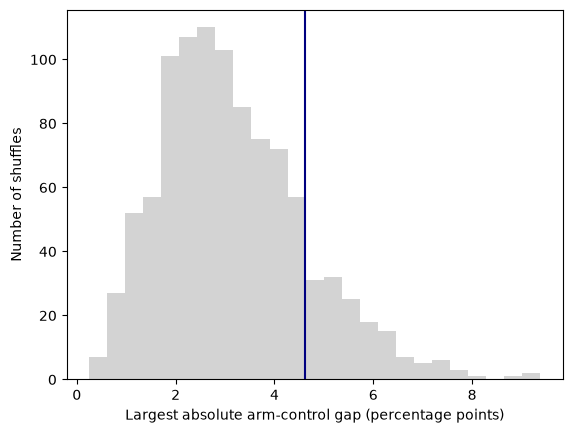

In [7]:
calibration_draws = np.abs(null_contrasts[:500])
evaluation_draws = np.abs(null_contrasts[500:])
pointwise_cutoffs = np.quantile(calibration_draws, 0.95, axis=0)
search_cutoff = np.quantile(calibration_draws.max(axis=1), 0.95)
print("Any pointwise rejection under the null:",
      np.mean((evaluation_draws > pointwise_cutoffs).any(axis=1)))
print("Search-adjusted rejection under the null:",
      np.mean(evaluation_draws.max(axis=1) > search_cutoff))
plt.hist(100 * null_max, bins=25, color="lightgray")
plt.axvline(100 * observed_max, color="navy")
plt.xlabel("Largest absolute arm-control gap (percentage points)")
plt.ylabel("Number of shuffles")
plt.show()


## Practice — write your own RI loop

Use only control and the **three-call** arm. In the cell below: create the subset; detach outcomes and labels into arrays; calculate the observed difference; create an empty list; then write a loop that shuffles labels, calculates the fake difference, and appends it. Finish with the two-sided p-value using `(1 + extreme_count) / (1 + repetitions)`. Use a fresh seed and 499 repetitions. The cell is intentionally empty of the solution; follow the preceding logic and write the steps yourself.

**Checks:** both arm counts stay fixed; labels sometimes change rows; outcomes do not change; the list has 499 numbers; the p-value is between 0 and 1. Explain why this arm must be chosen before seeing its estimate if you report its pointwise test alone.


In [8]:
# Write the subset, observed contrast, RI loop, and two-sided p-value here.


**Additional practice:** modify the selection statistic to choose the largest *positive* gap, rerun that same selection in every null draw, and explain the different question. Then describe how a survey response, turnout, and actual candidate choice differ as outcomes. The current dataset measures only turnout.

## Additional practice: NY recoding and grouped summaries

The following preserves useful geographic-data practice. These rows are Census Blocks; subgroup associations are observational. A registration tie is not a measured tie in votes or an estimated persuasion opportunity.


### 0. Environment preparation

We begin by loading the libraries we’ll need. In Python, libraries are like toolkits: they extend the language with specialized functions.

- **pandas (pd)** is our main tool for working with tabular data. It introduces the DataFrame, which lets us manipulate datasets in a way that feels natural if you’ve used Excel or R.
- **NumPy (np)** provides the numerical backbone. It gives us arrays and fast mathematical functions, which pandas actually uses under the hood.


### 1. Reading Dataset

This dataset was produced by the Redistricting Data Hub (RDH) using a voter file purchased from L2, a national voter file vendor, on March 9, 2021. The RDH retrieved and processed the data on April 16, 2021.

The original L2 voter file contains individual-level voter records. RDH aggregated these records to the 2010 Census Block level, identified by a GEOID constructed by concatenating County FIPS, Census Tract, and Census Block codes. In this way they were able to ceate counts for categorical variables such as party registration, gender, and modeled commercial data (e.g., likelihood of being a homeowner or magazine subscriptions).

To have a sense of what a Census Block is, you can take a look at this pdf of the [NYC Census Tracts Map](https://www.nyc.gov/assets/planning/download/pdf/about/publications/maps/nyc-census-tracts-map.pdf)


#### Codebook

This table describes the variables included in the dataset. The daset that we use in this coding session is a subset of the original dataset and can be accessesed via [Redistricting Data Hub](https://redistrictingdatahub.org/)

| Variable | Description | Modeled |
|----------|-------------|---------|
| `party_dem` | Count of voters registered with the Democratic Party (L2 Voter File) | No |
| `party_npp` | Count of voters registered with the Non-Partisan Party (L2 Voter File) | No |
| `party_rep` | Count of voters registered with the Republican Party (L2 Voter File) | No |
| `voters_gender_m` | Count of male voters | No |
| `voters_gender_f` | Count of female voters | No |
| `voters_gender_unknkown` | Count of voters with unknown or other gender | No |
| `commercialdatall_gun_owner` | Number of voters in Census Block who own guns based on gun registrations and subscriptions to gun/hunting magazines | No |
| `commercialdatall_home_owner_or_renter_likely_homeowner` | Count of voters likely to be homeowners | Modeled |
| `commercialdatall_home_owner_or_renter_likely_renter` | Count of voters likely to be renters | Modeled |
| `commercialdata_upscalebuyerinhome_avg` | Average number of upscale buyers in the home | Modeled |
| `commercialdata_familymagazineinhome_avg` | Average number of family magazines in the home | Modeled |
| `commercialdata_femaleorientedmagazineinhome_avg` | Average number of female-oriented magazines in the home | Modeled |
| `commercialdata_financialmagazineinhome_avg` | Average number of financial magazines in the home | Modeled |
| `commercialdata_gardeningmagazineinhome_avg` | Average number of gardening magazines in the home | Modeled |
| `commercialdata_healthfitnessmagazineinhome_avg` | Average number of health and fitness magazines in the home | Modeled |



In [9]:
from pathlib import Path

# Works from a session folder, the repository root, or a fresh Colab notebook.
data_candidates = [
    Path("data/nyvoterfile_2021.csv"),
    Path("wk04_message_testing/data/nyvoterfile_2021.csv"),
    Path("../wk04_message_testing/data/nyvoterfile_2021.csv"),
]
data_path = next((p for p in data_candidates if p.exists()), None)
data_url = "https://raw.githubusercontent.com/albertostefanelli/DSPC_coding_sessions/master/wk04_message_testing/data/nyvoterfile_2021.csv"
df_voterfile = pd.read_csv(data_path if data_path is not None else data_url)
df_voterfile.head()


,geoid,party_dem,party_npp,party_rep,voters_gender_m,voters_gender_f,voters_gender_unknkown,commercialdatall_gun_owner,commercialdatall_home_owner_or_renter_likely_homeowner,commercialdatall_home_owner_or_renter_likely_renter,commercialdata_upscalebuyerinhome_avg,commercialdata_familymagazineinhome_avg,commercialdata_femaleorientedmagazineinhome_avg,commercialdata_financialmagazineinhome_avg,commercialdata_gardeningmagazineinhome_avg,commercialdata_healthfitnessmagazineinhome_avg
0,360593009005012,15,42,15,39,37,0,4,45,18,NaN,2.0,1.0,1.0,NaN,2.0
1,360710117023032,1,0,2,0,3,0,2,1,0,NaN,NaN,NaN,NaN,NaN,3.0
2,360550129004023,16,11,2,13,17,0,2,21,3,NaN,1.0,NaN,1.0,1.0,2.0
3,360271000001013,0,1,2,2,1,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
4,360359706003096,1,0,4,3,2,0,0,2,1,NaN,NaN,NaN,NaN,1.0,2.0


### Recoding the largest included registration category

Retain the nested `np.where` example: compare the three supplied party shares and label tied maxima. This is a plurality among included categories, not necessarily a majority of all registered voters. Undefined shares require their own category.


In [10]:
# Previous coding session code ----------------------------------------------
# We want to calculate total voters and their share by party.

# 1. Total voters = sum of partisan categories
df_voterfile["total_voters"] = (
    df_voterfile["party_dem"]
    + df_voterfile["party_rep"]
    + df_voterfile["party_npp"]
)

# 2. Percentages by party

df_voterfile["pct_dem"] = df_voterfile["party_dem"] / df_voterfile["total_voters"]
df_voterfile["pct_rep"] = df_voterfile["party_rep"] / df_voterfile["total_voters"]
df_voterfile["pct_npp"] = df_voterfile["party_npp"] / df_voterfile["total_voters"]

# 3. Add a check column: percentages should add up to 1

df_voterfile["pct_total"] = (
    df_voterfile["pct_dem"]
    + df_voterfile["pct_rep"]
    + df_voterfile["pct_npp"]
)

# 4. Inspect the new columns
df_voterfile[["party_dem",
              "party_rep",
              "party_npp",
              "total_voters",
              "pct_dem",
              "pct_rep",
              "pct_npp",
              "pct_total"]].head()



,party_dem,party_rep,party_npp,total_voters,pct_dem,pct_rep,pct_npp,pct_total
0,15,15,42,72,0.208333,0.208333,0.583333,1.0
1,1,2,0,3,0.333333,0.666667,0.000000,1.0
2,16,2,11,29,0.551724,0.068966,0.379310,1.0
3,0,2,1,3,0.000000,0.666667,0.333333,1.0
4,1,4,0,5,0.200000,0.800000,0.000000,1.0


In [11]:
df_voterfile["majority_party"] = np.where(
    (df_voterfile["pct_dem"] > df_voterfile["pct_rep"]) &
    (df_voterfile["pct_dem"] > df_voterfile["pct_npp"]), "Dem",
    np.where(
        (df_voterfile["pct_rep"] > df_voterfile["pct_dem"]) &
        (df_voterfile["pct_rep"] > df_voterfile["pct_npp"]), "Rep",
        np.where(
            (df_voterfile["pct_npp"] > df_voterfile["pct_dem"]) &
            (df_voterfile["pct_npp"] > df_voterfile["pct_rep"]), "NPP",
            "Tie"
        )
    )
)


df_voterfile.loc[df_voterfile["total_voters"] == 0, "majority_party"] = "Undefined"

# Check distribution
df_voterfile["majority_party"].value_counts(normalize=True)

majority_party
Dem          0.454308
Rep          0.340100
NPP          0.110783
Tie          0.090421
Undefined    0.004388
Name: proportion, dtype: float64

1. **First condition:**  
   `(pct_dem > pct_rep) & (pct_dem > pct_npp)`  
   - This checks if the Democratic share is **bigger than both Republican and Non-partisan shares**.  
   - If true: label the row `"Dem"`.  

2. **Second condition:**  
   `(pct_rep > pct_dem) & (pct_rep > pct_npp)`  
   - Only runs if the first condition was false.  
   - Checks if Republicans have the largest share.  
   - If true: label the row `"Rep"`.  

3. **Third condition:**  
   `(pct_npp > pct_dem) & (pct_npp > pct_rep)`  
   - Runs if both earlier conditions were false.  
   - Checks if Non-partisans have the largest share.  
   - If true: label the row `"NPP"`.  

4. **Default (else):**  
   `"Tie"`  
   - If none of the conditions are true (e.g., two or more groups have the same max value), we assign `"Tie"`.  

After recoding, zero-denominator rows are marked `Undefined`, not interpreted as ties.


### 2. Summarise by group

We have two variables:

- `commercialdatall_gun_owner`: the recorded count of gun owners in each Census Block.
- `total_voters`: our sum of Democratic, Republican, and non-partisan registrations, which excludes other categories.

We classified blocks by the largest included registration category (`majority_party`). We now calculate `commercialdatall_gun_owner / total_voters`, then use `groupby("majority_party")` to average that ratio across blocks. Read it as **recorded gun owners per included-category voter**, not the share of all voters who own guns. The numerator and denominator need not describe the same set of individuals; ratios above one are a warning about that mismatch.

Which group has the highest mean ratio? Which has the lowest? A group mean weights blocks equally, so small and large blocks count the same. These comparisons do not describe the ownership rate of Democratic or Republican individuals.


In [12]:
# Step 1: Calculate a count ratio using the available denominator
df_voterfile["pct_gunowners"] = df_voterfile["commercialdatall_gun_owner"] / df_voterfile["total_voters"]

In [13]:
# Step 2: Summarize by majority party
gunowner_summary = df_voterfile.groupby("majority_party")["pct_gunowners"].mean()

# Step 3: Display results
gunowner_summary

majority_party
Dem          0.097247
NPP          0.133039
Rep          0.175402
Tie          0.146205
Undefined         inf
Name: pct_gunowners, dtype: float64

### Why do we have `inf` or missing values?

Our denominator sums only Democratic, Republican, and non-partisan registrations. It can be zero even if another field has a positive count; it is not a count of every registered voter. Dividing a positive value by zero produces infinity; zero divided by zero is undefined. Inspect those rows before excluding them from a ratio. A numerator can also exceed the included-category denominator: that ratio should not be described as an all-voter ownership probability. The next steps filter undefined ratios and report how many rows they exclude.


In [14]:
# let's check where the total_voters are
df_voterfile[df_voterfile["total_voters"] == 0]

,geoid,party_dem,party_npp,party_rep,voters_gender_m,voters_gender_f,voters_gender_unknkown,commercialdatall_gun_owner,commercialdatall_home_owner_or_renter_likely_homeowner,commercialdatall_home_owner_or_renter_likely_renter,...,commercialdata_financialmagazineinhome_avg,commercialdata_gardeningmagazineinhome_avg,commercialdata_healthfitnessmagazineinhome_avg,total_voters,pct_dem,pct_rep,pct_npp,pct_total,majority_party,pct_gunowners
35,360290137012009,0,0,0,0,1,0,0,0,0,...,2.0,3.0,2.0,0,NaN,NaN,NaN,NaN,Undefined,NaN
92,361130707011002,0,0,0,0,1,0,0,0,0,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Undefined,NaN
300,360670144002071,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Undefined,NaN
522,360150109001012,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Undefined,NaN
696,360910615001069,0,0,0,0,1,0,0,0,0,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Undefined,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237917,360870109021019,0,0,0,0,1,0,0,0,1,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Undefined,NaN
238170,360750201004046,0,0,0,2,1,0,1,0,0,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Undefined,inf
238323,361031349071039,0,0,0,1,1,0,0,2,0,...,NaN,NaN,2.0,0,NaN,NaN,NaN,NaN,Undefined,NaN
238559,360690514002008,0,0,0,0,1,0,0,0,1,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Undefined,NaN


In [15]:
df_voterfile_no0 = df_voterfile.loc[df_voterfile["total_voters"] > 0].copy()
print("Undefined denominator rows:", int((df_voterfile["total_voters"] == 0).sum()))
print("Ratios above one:", int((df_voterfile_no0["pct_gunowners"] > 1).sum()))
df_voterfile_no0.groupby("majority_party")["pct_gunowners"].mean()


Undefined denominator rows: 1048
Ratios above one: 164


majority_party
Dem    0.097247
NPP    0.133039
Rep    0.175402
Tie    0.146205
Name: pct_gunowners, dtype: float64

In [16]:
# One assignment method is enough: initialize, then update selected rows.
df_voterfile_no0["tie_high_gunowners"] = 0
df_voterfile_no0.loc[
    (df_voterfile_no0["majority_party"] == "Tie") &
    (df_voterfile_no0["pct_gunowners"] > 0.3),
    "tie_high_gunowners"
] = 1
df_voterfile_no0["tie_high_gunowners"].value_counts(normalize=True) * 100


tie_high_gunowners
0    98.612998
1     1.387002
Name: proportion, dtype: float64